
# Линейная регрессия. Практическая работа

## Цель практической работы

Научиться строить модель линейной регрессии на реальных данных.

## Что входит в практическую работу


1. Загрузить данные и ознакомиться с ними.
2. Изучить данные и провести анализ.
3. Разделить данные на обучающую и тестовую выборки.
4. Реализовать построение модели с помощью  библиотеки scikit-learn.
5. Получить качество модели с помощью MSE, MAE.


## Что оценивается 

* Выполнены все этапы работы.
* Сделан вывод по результатам.
* Модель не переобучена.
* Получена модель хорошего качества.

## Как отправить работу на проверку

Скачайте файл с заданиями в материалах, откройте его через Jupyter Notebook и выполните задачи. Сохраните изменения при помощи опции Save and Checkpoint из вкладки меню File или кнопки Save and Checkpoint на панели инструментов. Отправьте через форму ниже итоговый файл Jupyter Notebook (в формате .ipynb) или ссылку на него.



## Что нужно сделать

Пусть у нас имеется некоторый набор данных `sales.csv` о продажах квартир:

- **SalePrice** (цена продажи, *зависимая переменная*).
- **GrLivArea** (наземная жилая зона).
- **OverallQuality** (общее качество).
- **GarageArea** (территория гаража).
- **SaleCondition** (условия сделки).

Реализуйте построение модели линейной регрессии на этих данных. Проверьте качество модели на обучающей и тестовой выборках с помощью MAE, MSE. Определите, что вы не переобучились.

### 1. Импорт библиотек

In [27]:
# Ваш код здесь
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

### 2. Загрузка данных

In [3]:
# Ваш код здесь
df = pd.read_csv('sales.csv')
df.head()

,SalePrice,GrLivArea,GarageArea,OverallQual,Street,SaleCondition
0,208500,1710,548,7,Pave,Normal
1,181500,1262,460,6,Pave,Normal
2,223500,1786,608,7,Pave,Normal
3,140000,1717,642,7,Pave,Abnorml
4,250000,2198,836,8,Pave,Normal


### 3. Первичный анализ

1. Проведите анализ данных, посмотрите на индивидуальные графики зависимости целевой функции и отдельной переменной. Нередко, если признаков в выборке не так много, удобно построить [sns.pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html).
2. Закодируйте категориальные признаки (например, с помощью [pd.get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)).
3. Подумайте, можно ли здесь создать дополнительные переменные из имеющихся.
4. Сделайте предварительные выводы.

In [9]:
df.isnull().sum() 

SalePrice        0
GrLivArea        0
GarageArea       0
OverallQual      0
Street           0
SaleCondition    0
dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   SalePrice      1460 non-null   int64
 1   GrLivArea      1460 non-null   int64
 2   GarageArea     1460 non-null   int64
 3   OverallQual    1460 non-null   int64
 4   Street         1460 non-null   str  
 5   SaleCondition  1460 non-null   str  
dtypes: int64(4), str(2)
memory usage: 68.6 KB


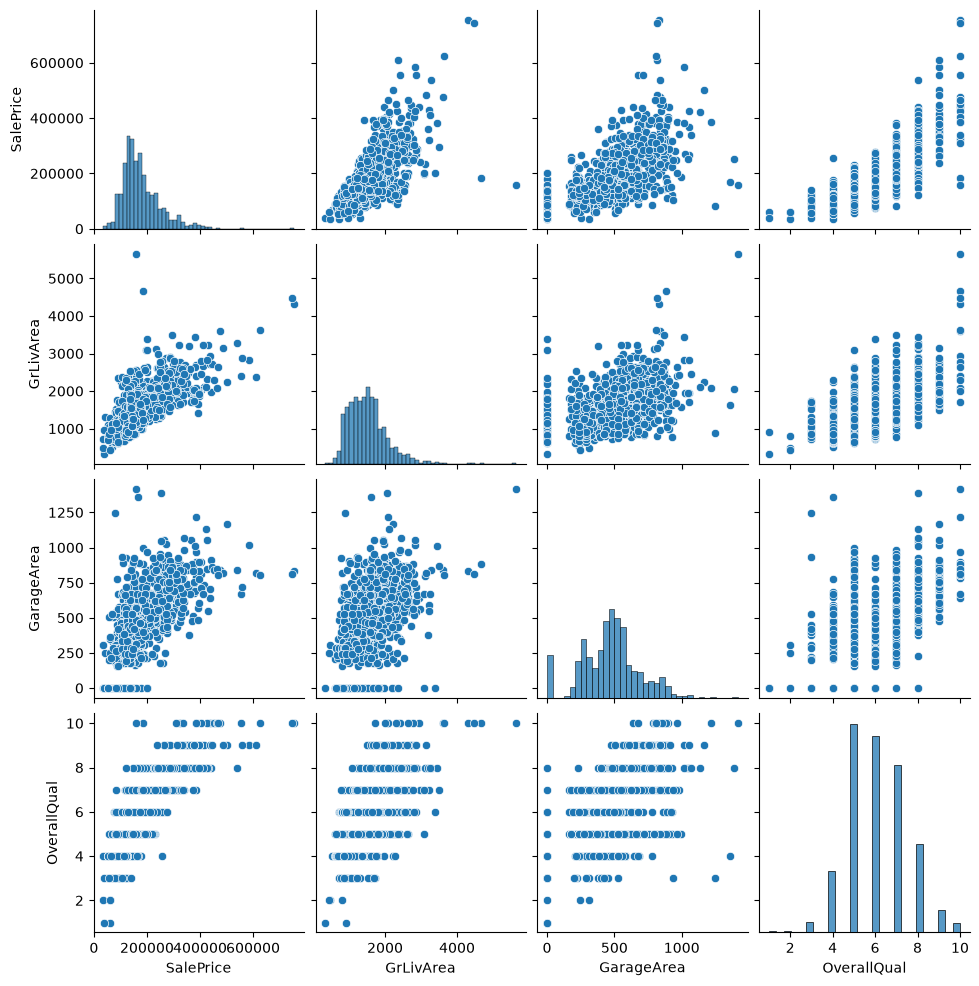

In [7]:
# Ваш код здесь
sns.pairplot(df)

In [14]:
df.columns

Index(['SalePrice', 'GrLivArea', 'GarageArea', 'OverallQual', 'Street',
       'SaleCondition'],
      dtype='str')

In [19]:
df['Street'].value_counts()

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

сильный imbalance, хз

In [20]:
df['SaleCondition'].value_counts()

SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64

### 4. Разделение на обучающую и тестовую выборки

In [21]:
# Ваш код здесь
X = df.drop(columns='SalePrice')
y = df['SalePrice']

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42)

кодируем текстовые переменные:

In [22]:
cat_cols = x_train.select_dtypes(include='object').columns.tolist()

encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

x_train_encoded = encoder.fit_transform(x_train[cat_cols])
x_test_encoded = encoder.transform(x_test[cat_cols])

x_train_encoded_df = pd.DataFrame(x_train_encoded, columns=encoder.get_feature_names_out(cat_cols), index=x_train.index)
x_test_encoded_df = pd.DataFrame(x_test_encoded, columns=encoder.get_feature_names_out(cat_cols), index=x_test.index)

x_train = pd.concat([x_train.drop(columns=cat_cols), x_train_encoded_df], axis=1)
x_test = pd.concat([x_test.drop(columns=cat_cols), x_test_encoded_df], axis=1)

C:\Users\Arsenii\AppData\Local\Temp\ipykernel_1600\2894205984.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_train.select_dtypes(include='object').columns.tolist()


### 5. Обучение модели линейной регрессии

Дополнительно можно взглянуть на коэффициенты и смещение обученной модели.

In [23]:
# Ваш код здесь
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 46.22, 68.57, 26661.65,...,-11832.29, 7652.25, 35284.83]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['GrLivArea','GarageArea','OverallQual',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.922e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [24]:
lr.coef_

array([    46.22043732,     68.57263275,  26661.65375602, -15327.96876356,
         9830.57220702,  35046.63521939, -11832.29041096,   7652.24622845,
        35284.83471607])

In [25]:
lr.intercept_

np.float64(-79220.46670953327)

### 6. Получение предсказаний для обучающей и тестовой выборок

In [26]:
# Ваш код здесь
y_test_pred = lr.predict(x_test)
y_train_pred = lr.predict(x_train)

### 7. Проверка предсказаний

1. Проверьте качество модели на обучающей и тестовой выборках с помощью MAE, MSE.
2. Постройте диаграмму рассеяния целевой и предсказанной переменных. 

In [32]:
# Ваш код здесь
print(f'train MAE: {mean_absolute_error(y_train, y_train_pred)}')
print(f'test MAE: {mean_absolute_error(y_test, y_test_pred)}')
print('-' * 25)
print(f'train MSE: {mean_squared_error(y_train, y_train_pred)}')
print(f'test MSE: {mean_squared_error(y_test, y_test_pred)}')

train MAE: 26373.183982701772
test MAE: 26854.810713448136
-------------------------
train MSE: 1587577269.1488261
test MSE: 1625783935.4336717


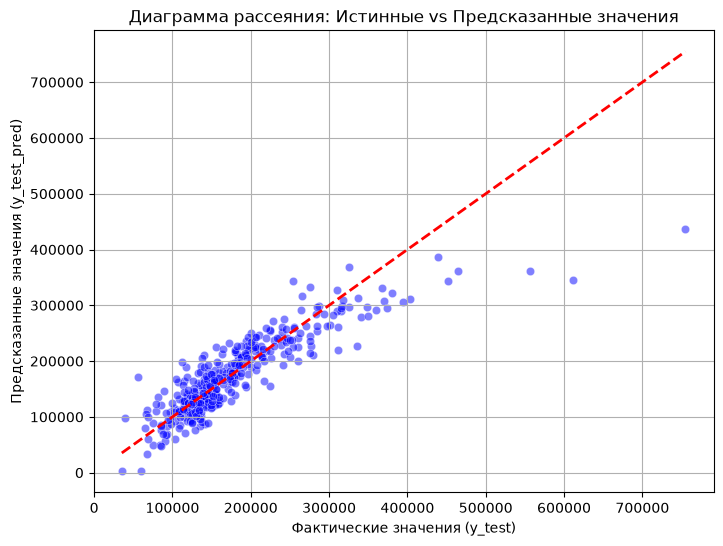

In [33]:
# Настройка размера графика
plt.figure(figsize=(8, 6))

# Построение диаграммы рассеяния (для тестовой выборки)
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5, color='blue')

# Добавление идеальной линии прогноза (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# Названия осей и графика
plt.xlabel('Фактические значения (y_test)')
plt.ylabel('Предсказанные значения (y_test_pred)')
plt.title('Диаграмма рассеяния: Истинные vs Предсказанные значения')
plt.grid(True)

# Отображение
plt.show()


Судя по графику, модель хорошо справляется с предсказанием недорогих объектов, но систематически ошибается на дорогих

Модель не переобучена (MAE и MSE близки на train/test). Качество среднее - ошибка ~15% от цены. Для улучшения можно попробовать логарифмировать SalePrice, убрать выбросы по GrLivArea, добавить больше признаков